In [4]:
import warnings

warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import matplotlib as mat
import os
import seaborn as sns
import numpy as np
import matplotlib.ticker as mticker
import ast
import json
from matplotlib import colors
from PIL import ImageColor
import glob
import matplotlib.ticker as ticker
import pathlib
import scipy.stats as st
from scipy.optimize import curve_fit
from scipy.stats import poisson, norm
from brokenaxes import brokenaxes

from sklearn import preprocessing
import re

import scipy.stats as st

from fitter import Fitter

# %#config IPCompleter.greedy=True
# %#matplotlib notebook
# %#matplotlib inline
plt.rcParams["figure.figsize"] = [4, 4]

POINT_PLOT_DODGE = 0.15
sns.set(font_scale=1.25, style="ticks")
FIGSIZE = [6, 6]
plt.style.use("tableau-colorblind10")
# PALETTE = sns.cubehelix_palette(as_cmap\=False, n_colors=3, reverse=False, light=0.7)
print("hot stuff")

hot stuff


In [6]:
base_dir = "/home/rubinhus/Documents/phd/thesis/backpressure/data/2544/"
rest_of_path = "Run0001/AggregateResults.csv"

all_dfs = []

# Find every AggregateResults.csv under 2544/*
csv_files = glob.glob(os.path.join(base_dir, "*/*", rest_of_path))

for path in csv_files:
    folder_name = os.path.basename(os.path.dirname(path))  # e.g., b1.1_l3_200_1WT_0HT_NoSMT

    if 'skip' in path:
        continue
    
    # Split folder name into components safely
    folder = path.split("/")
    # Some directories may not follow exact pattern: guard length
    
    # print(folder)
    try:
        ninstances = int(folder[-3].strip('instance'))
        experiment = folder[-4]
        # ntc = parts[-2] if len(parts) > 2 else None
    
        # print(folder)
        df = pd.read_csv(path)
        df["Instance"] = ninstances
        df['Experiment'] = experiment

        all_dfs.append(df)
    except Exception as e:
        print(f"Failed to parse {folder_name}: {e}")

# Combine all datasets
combined_df = pd.concat(all_dfs, ignore_index=True)

# Optional: sort or save
# combined_df = combined_df.sort_values(by="source")
# combined_df.to_csv("/home/rubinhus/combined_aggregateresults.csv", index=False)

print(f"Loaded {len(combined_df)} rows from {len(all_dfs)} files")

Loaded 168 rows from 8 files


In [7]:
combined_df

,Trial,Framesize,Iteration,Agg Tx Rate (% Line Rate),Agg Rx Throughput (% Line Rate),Agg Rx Throughput (fps),Agg Rx Throughput (Mbps),Agg Tx Count (frames),Agg Rx Count (frames),Agg Frame Loss (frames),Agg Frame Loss (%),Min Latency (ns),Max Latency (ns),Avg Latency (ns),Stream Duration (s),Instance,Experiment
0,1,72,8,23.359,23.359,3.173826e+07,18281.239,1.872559e+09,1.872559e+09,0.0,0.0,33015.0,739130.0,79671.00,59,4,std
1,1,128,7,36.718,36.718,3.101244e+07,31756.741,1.829735e+09,1.829735e+09,0.0,0.0,33922.0,339032.0,71982.75,59,4,std
2,1,256,8,68.359,68.359,3.095984e+07,63405.761,1.826632e+09,1.826632e+09,0.0,0.0,33562.0,840457.0,77759.25,59,4,std
3,1,512,9,100.000,100.000,2.349623e+07,96240.576,1.386278e+09,1.386278e+09,0.0,0.0,34125.0,74052.0,51422.75,59,4,std
4,1,1024,9,100.000,100.000,1.197318e+07,98084.275,7.064176e+08,7.064176e+08,0.0,0.0,33987.0,53630.0,44223.00,59,4,std
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,3,256,8,34.609,34.609,1.567452e+07,32101.408,9.247976e+08,9.247976e+08,0.0,0.0,33115.0,312430.0,129622.00,59,2,pab
164,3,512,4,66.250,66.250,1.556624e+07,63759.305,9.184093e+08,9.184093e+08,0.0,0.0,34325.0,330685.0,135441.00,59,2,pab
165,3,1024,9,100.000,100.000,1.197318e+07,98084.260,7.064176e+08,7.064176e+08,0.0,0.0,33470.0,73292.0,53507.00,59,2,pab
166,3,1280,9,100.000,100.000,9.615383e+06,98461.521,5.673077e+08,5.673077e+08,0.0,0.0,33847.0,106477.0,45064.50,59,2,pab


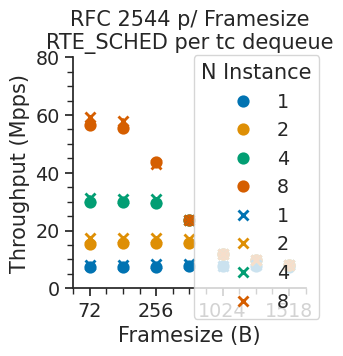

In [8]:
# Plot using pointplot with hue=dodge
fig, ax1 = plt.subplots(1,1, figsize=(3,3))

p_df = combined_df[combined_df['Experiment'] == 'pab']
sns.pointplot(
    data = p_df,
    x = p_df['Framesize'].astype(int),
    y = p_df['Agg Rx Throughput (fps)']/1E6,
    hue = p_df['Instance'].astype(int),
    ax=ax1,
    errorbar='sd',
    palette = 'colorblind',
    linestyle=None,
    join=False,
)

p_df = combined_df[combined_df['Experiment'] == 'std']
sns.pointplot(
    data = p_df,
    x = p_df['Framesize'].astype(int),
    y = p_df['Agg Rx Throughput (fps)']/1E6,
    hue = p_df['Instance'].astype(int),
    ax=ax1,
    errorbar='sd',
    palette = 'colorblind',
    marker='x',
    linestyle=None,
    join=False,
)


ax1.set_ylim(0, 80)

ax1.set_ylabel('Throughput (Mpps)')
ax1.set_xlabel('Framesize (B)')

ax1.set_title('RFC 2544 p/ Framesize\nRTE_SCHED per tc dequeue')

# Ticks
ax1.xaxis.set_major_locator(ticker.AutoLocator())
ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax1.yaxis.set_major_locator(ticker.AutoLocator())
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())

legend2 = ax1.legend(title = 'N Instance',
    loc="upper right", bbox_to_anchor=(1.1, 1.05)
)

sns.despine()

# plt.tight_layout()
# fig.savefig('/home/rubinhus/Documents/phd/thesis/backpressure/plots/rfc2544_pertc_dequeue.pdf', bbox_inches="tight")

In [71]:
combined_df.columns

Index(['Trial', 'Framesize', 'Iteration', 'Agg Tx Rate (% Line Rate)',
       'Agg Rx Throughput (% Line Rate)', 'Agg Rx Throughput (fps)',
       'Agg Rx Throughput (Mbps)', 'Agg Tx Count (frames)',
       'Agg Rx Count (frames)', 'Agg Frame Loss (frames)',
       'Agg Frame Loss (%)', 'Min Latency (ns)', 'Max Latency (ns)',
       'Avg Latency (ns)', 'Stream Duration (s)', 'Instance', 'Experiment'],
      dtype='object')

In [12]:
# Step 1: Compute mean throughput per group
throughput_mean = (
    combined_df
    .groupby(['Experiment', 'Framesize', 'Instance'])
    [['Agg Rx Throughput (fps)']]
    .mean()
    .reset_index()
)

# Step 2: Separate baseline (default)
baseline = throughput_mean[throughput_mean['Experiment'] == 'std'] \
    .set_index(['Framesize', 'Instance'])

# Step 3: Join baseline back to compute delta
comparison = throughput_mean.set_index(['Framesize', 'Instance']).join(
    baseline[['Agg Rx Throughput (fps)']], rsuffix='_default'
).reset_index()

# Step 4: Compute normalized delta (%)
comparison['Throughput Overhead (%)'] = (
    (comparison['Agg Rx Throughput (fps)'] - comparison['Agg Rx Throughput (fps)_default'])
    / comparison['Agg Rx Throughput (fps)_default']
) * 100

# Step 5: Optional: remove default rows (baseline) for clarity
overhead_df = comparison[comparison['Experiment'] != 'std']

# Step 6: Round for presentation
overhead_df = overhead_df.round({'Throughput Overhead (%)': 2, 'Agg Rx Throughput (fps)': 2})

overhead_df


,Framesize,Instance,Experiment,Agg Rx Throughput (fps),Agg Rx Throughput (fps)_default,Throughput Overhead (%)
0,72,1,pab,7218068.92,7.982333e+06,-9.57
2,72,2,pab,15497611.01,1.740826e+07,-10.98
4,72,4,pab,29827601.84,3.110138e+07,-4.10
6,72,8,pab,56576889.35,5.944289e+07,-4.82
8,128,1,pab,7337413.56,7.970858e+06,-7.95
10,128,2,pab,15572194.19,1.735376e+07,-10.27
12,128,4,pab,29824736.63,3.101244e+07,-3.83
14,128,8,pab,55360507.00,5.793386e+07,-4.44
16,256,1,pab,7501122.74,8.244164e+06,-9.01
18,256,2,pab,15674514.96,1.726674e+07,-9.22


In [3]:
result = (
    combined_df
    .groupby(['Experiment', 'Framesize', 'Instance'])
    # ['Agg Rx Throughput (fps)']
     [['Min Latency (ns)','Avg Latency (ns)', 'Max Latency (ns)']]
     .mean() - 23957
)/1E3

result = result.applymap(lambda x: float(f'{x:.5g}'))
result

Min Latency (ns)  Avg Latency (ns)  \
Experiment Framesize Instance                                       
pab        72        1                   9.5587            37.067   
                     2                   9.9480            63.908   
                     4                   8.6220            46.585   
                     8                   8.7727            59.789   
           128       1                   9.5493            42.832   
                     2                   9.3127            98.718   
                     4                   8.8760            56.004   
                     8                   8.7310            67.671   
           256       1                  10.1460            53.773   
                     2                   9.8397           105.400   
                     4                   8.9570            59.784   
                     8                   9.1767            23.928   
           512       1                  10.1870            69.413   
                     2                  10.5820           109.070   
                     4                   9.3527            26.971   
                     8                   9.3413            19.701   
           1024      1                   9.9580            74.843   
                     2                   9.8893            29.861   
                     4                   9.0510            18.737   
                     8                   8.5820            19.581   
           1280      1                  10.1740            72.243   
                     2                   9.7860            21.050   
                     4                   9.4610            18.692   
                     8                   9.0063            22.051   
           1518      1                  11.4430            76.775   
                     2                  10.6120            20.027   
                     4                   9.1527            18.377   
                     8                   9.0477            21.566   
std        72        1                  10.4890            46.736   
                     2                   9.7243            96.881   
                     4                   9.5653            42.580   
                     8                   9.1587            75.053   
           128       1                   9.5293            50.267   
                     2                   9.7660           104.370   
                     4                   9.5103            47.915   
                     8                   9.5800            86.117   
           256       1                  11.1050            65.776   
                     2                  10.4570           105.740   
                     4                   9.6977            54.291   
                     8                   9.9313            24.699   
           512       1                  10.8750            69.246   
                     2                  11.0400           109.740   
                     4                  10.2450            27.637   
                     8                   9.6483            20.792   
           1024      1                  10.7770            51.969   
                     2                  10.1520            31.149   
                     4                   9.9283            20.260   
                     8                   9.7470            21.856   
           1280      1                  10.5540            65.654   
                     2                  10.5360            23.365   
                     4                   9.9353            20.358   
                     8                   9.4697            23.897   
           1518      1                  11.0880            73.136   
                     2                  10.9250            20.733   
                     4                  10.1130            20.402   
                     8                   9.4900            22.159   

                            

KeyError: 'Nsessions'

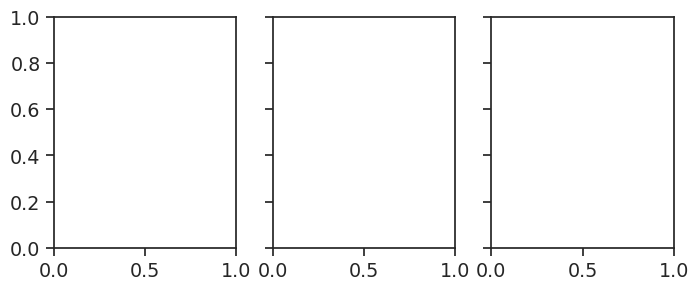

In [11]:
# Plot using pointplot with hue=dodge
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 3), sharey=True)

# Prepare data
plot_df = combined_df.copy()
plot_df["Throughput (Mpps)"] = plot_df["Agg Rx Throughput (fps)"] / 1e6

# Filter for 200 and 4k sessions, exclude HT=0
plot_df = plot_df[plot_df["Nsessions"].isin(["200", "4k"])]
plot_df = plot_df[plot_df["HT"] != "0"]

# Colors for WT/HT combos
wt_ht_colors = {
    "1-1": "blue",
    "8-1": "orange",
    "8-8": "green",
}

# Marker style by session count
session_markers = {"200": "o", "4k": "x"}

# Create a combined column for WT/HT
plot_df["WT_HT"] = plot_df["WT"] + "-" + plot_df["HT"]

p_df = plot_df[plot_df["Hyperthreading"] == "NoSMT"]
sns.pointplot(
    data=p_df[p_df["Nsessions"] == "200"],
    x="Framesize",
    y="Throughput (Mpps)",
    hue="WT_HT",  # separate 200 vs 4k
    # dodge=0.3,  # horizontal offset for session counts
    join=False,
    ci="sd",  # show error bars
    scale=0.8,
    palette=wt_ht_colors,
    ax=ax1,
    legend=False,
)

sns.pointplot(
    data=p_df[p_df["Nsessions"] == "4k"],
    x="Framesize",
    y="Throughput (Mpps)",
    hue="WT_HT",  # separate 200 vs 4k
    # dodge=True,
    marker="x",
    join=False,
    ci="sd",  # show error bars
    scale=0.8,
    palette=wt_ht_colors,
    ax=ax1,
    legend=False,
)

p_df = plot_df[plot_df["Hyperthreading"] == "SMT-nosibling"]
sns.pointplot(
    data=p_df[p_df["Nsessions"] == "200"],
    x="Framesize",
    y="Throughput (Mpps)",
    hue="WT_HT",  # separate 200 vs 4k
    # dodge=0.3,  # horizontal offset for session counts
    join=False,
    ci="sd",  # show error bars
    scale=0.8,
    palette=wt_ht_colors,
    ax=ax2,
    legend=False,
)

sns.pointplot(
    data=p_df[p_df["Nsessions"] == "4k"],
    x="Framesize",
    y="Throughput (Mpps)",
    hue="WT_HT",  # separate 200 vs 4k
    # dodge=True,
    marker="x",
    join=False,
    ci="sd",  # show error bars
    scale=0.8,
    palette=wt_ht_colors,
    ax=ax2,
    legend=False,
)

p_df = plot_df[plot_df["Hyperthreading"] == "SMT-sibling"]
sns.pointplot(
    data=p_df[p_df["Nsessions"] == "200"],
    x="Framesize",
    y="Throughput (Mpps)",
    hue="WT_HT",  # separate 200 vs 4k
    # dodge=0.3,  # horizontal offset for session counts
    join=False,
    ci="sd",  # show error bars
    scale=1,
    palette=wt_ht_colors,
    ax=ax3,
    legend=False,
)

sns.pointplot(
    data=p_df[p_df["Nsessions"] == "4k"],
    x="Framesize",
    y="Throughput (Mpps)",
    hue="WT_HT",  # separate 200 vs 4k
    # dodge=True,
    marker="x",
    join=False,
    ci="sd",  # show error bars
    scale=0.8,
    palette=wt_ht_colors,
    ax=ax3,
    legend=False,
)

# --- Your custom legends ---
# Legend for session markers
marker_handles = [
    Line2D(
        [0],
        [0],
        marker=m,
        color="w",
        markerfacecolor="gray",
        markeredgecolor="black",
        lw=0,
        markersize=10,
        label=f"{s}",
    )
    for s, m in session_markers.items()
]
legend1 = ax3.legend(
    handles=marker_handles,
    title="N Sessions",
    loc="upper left",
    bbox_to_anchor=(1, 0.4),
)

# Legend for WT/HT colors
color_handles = [
    Line2D([0], [0], color=c, lw=2, label=f"{k}") for k, c in wt_ht_colors.items()
]
legend2 = ax3.legend(
    handles=color_handles, title="WT/HT", loc="upper left", bbox_to_anchor=(1, 1.05)
)

# Ticks
ax1.yaxis.set_major_locator(ticker.AutoLocator())
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())

# Axis labels and title
ax1.set_xlabel("Packet Size (B)")
ax2.set_xlabel("Packet Size (B)")
ax3.set_xlabel("Packet Size (B)")
ax1.set_ylabel("Throughput (Mpps)")

ax1.set_title("No SMT")
ax2.set_title("0% Drop Rate, L3 Forward and HQoS, Multiple Threading Configurations\nSMT No Sibling")
ax3.set_title("SMT Sibling")

# plt.setp(ax.get_xticklabels(), rotation=20)
ax1.set_ylim(0, 50)

# Add the first legend back as an artist so both show
ax3.add_artist(legend1)
sns.despine()

# plt.tight_layout()
# plt.show()
# fig.savefig('/home/rubinhus/Documents/phd/thesis/bng_offload/plots/bng_offload/baseline/baseline.png', bbox_inches="tight")

In [ ]:
# Filter the dataframe
p_df = combined_df[combined_df["Hyperthreading"] == "NoSMT"]


# Create figure
fig, ax1 = plt.subplots(figsize=[3.5, 3])

# Define styles: consistent markers, varied line styles, minimal colors
styles = [
    {
        "WT": "1",
        "HT": "0",
        "linestyle": "solid",
        "color": "#006BA4",
        "label": "WT=1, HT=0",
        "markerstyle": "x",
    },
    {
        "WT": "8",
        "HT": "0",
        "linestyle": "dashed",
        "color": "#FF800E",
        "label": "WT=8, HT=0",
        "markerstyle": "x",
    },
    {
        "WT": "1",
        "HT": "1",
        "linestyle": "dotted",
        "color": "#ABABAB",
        "label": "WT=1, HT=1",
        "markerstyle": "o",
    },
    {
        "WT": "8",
        "HT": "1",
        "linestyle": "dashdot",
        "color": "#595959",
        "label": "WT=8, HT=1",
        "markerstyle": "o",
    },
    {
        "WT": "8",
        "HT": "8",
        "linestyle": "solid",
        "color": "#5F9ED1",
        "label": "WT=8, HT=8",
        "markerstyle": "o",
    },
]

# Plot each configuration
for s in styles:
    t_df = p_df[(p_df["WT"] == s["WT"]) & (p_df["HT"] == s["HT"])]
    sns.pointplot(
        data=t_df,
        x="Framesize",
        y=t_df["Agg Rx Throughput (fps)"] / 10**6,
        join=False,
        ax=ax1,
        marker=s["markerstyle"],
        color=s["color"],
        markersize=8,
        # linestyle=s["linestyle"],
        linestyle=None,
        linewidth=2,
    )

# Axis labels and title
ax1.set_xlabel("Packet Size (B)")
ax1.set_ylabel("Throughput (Mpps)")
ax1.set_title("RFC 2544 Throughput vs Packet Size\nL3 Forward, 200 sessions, No SMT")
ax1.set_ylim(0, 105)

# Ticks
ax1.yaxis.set_major_locator(ticker.AutoLocator())
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax1.xaxis.set_major_locator(ticker.AutoLocator())

# Build legend handles manually
legend_elements = [
    Line2D(
        [0],
        [0],
        color=s["color"],
        marker=s["markerstyle"],
        linestyle=None,
        lw=0,
        markersize=6,
        label=s["label"],
    )
    for s in styles
]

ax1.legend(
    handles=legend_elements,
    title="Thread Configuration",
    loc="upper left",
    bbox_to_anchor=(1.05, 1),
)

# Remove top/right spines and tighten layout
sns.despine()
plt.tight_layout()
plt.show()

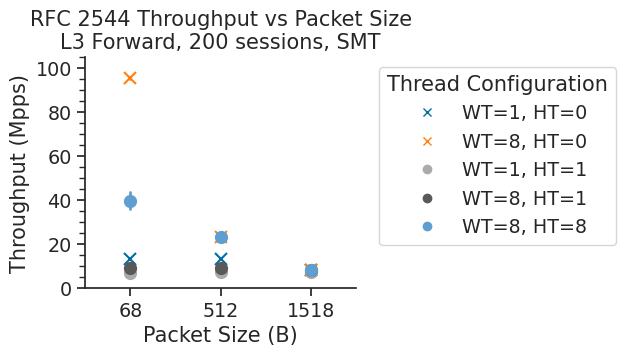

In [101]:
# Filter the dataframe
p_df = combined_df[combined_df["Hyperthreading"] != "NoSMT"]
p_df = p_df[
    ~p_df["Hyperthreading"].str.contains("SMT-sibling", na=False)
]

# Create figure
fig, ax1 = plt.subplots(figsize=[3.5, 3])

# Define styles: consistent markers, varied line styles, minimal colors
styles = [
    {
        "WT": "1",
        "HT": "0",
        "linestyle": "solid",
        "color": "#006BA4",
        "label": "WT=1, HT=0",
        "markerstyle": "x",
    },
    {
        "WT": "8",
        "HT": "0",
        "linestyle": "dashed",
        "color": "#FF800E",
        "label": "WT=8, HT=0",
        "markerstyle": "x",
    },
    {
        "WT": "1",
        "HT": "1",
        "linestyle": "dotted",
        "color": "#ABABAB",
        "label": "WT=1, HT=1",
        "markerstyle": "o",
    },
    {
        "WT": "8",
        "HT": "1",
        "linestyle": "dashdot",
        "color": "#595959",
        "label": "WT=8, HT=1",
        "markerstyle": "o",
    },
    {
        "WT": "8",
        "HT": "8",
        "linestyle": "solid",
        "color": "#5F9ED1",
        "label": "WT=8, HT=8",
        "markerstyle": "o",
    },
]

# Plot each configuration
for s in styles:
    t_df = p_df[(p_df["WT"] == s["WT"]) & (p_df["HT"] == s["HT"])]
    sns.pointplot(
        data=t_df,
        x="Framesize",
        y=t_df["Agg Rx Throughput (fps)"] / 10**6,
        join=False,
        ax=ax1,
        marker=s['markerstyle'],
        color=s["color"],
        markersize=8,
        # linestyle=s["linestyle"],
        linestyle=None,
        linewidth=2,
    )

# Axis labels and title
ax1.set_xlabel("Packet Size (B)")
ax1.set_ylabel("Throughput (Mpps)")
ax1.set_title("RFC 2544 Throughput vs Packet Size\nL3 Forward, 200 sessions, SMT")
ax1.set_ylim(0, 105)

# Ticks
ax1.yaxis.set_major_locator(ticker.AutoLocator())
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax1.xaxis.set_major_locator(ticker.AutoLocator())

# Build legend handles manually
legend_elements = [
    Line2D(
        [0],
        [0],
        color=s["color"],
        marker=s['markerstyle'],
        linestyle=None,
        lw=0,
        markersize=6,
        label=s["label"],
    )
    for s in styles
]

ax1.legend(
    handles=legend_elements,
    title="Thread Configuration",
    loc="upper left",
    bbox_to_anchor=(1.05, 1),
)

# Remove top/right spines and tighten layout
sns.despine()
plt.tight_layout()
plt.show()

In [29]:
base_dir = "/home/rubinhus/code/datasets/backpressure/2544/"
rest_of_path = "Run0001/AggregateResults.csv"

all_dfs = []

# Find every AggregateResults.csv under 2544/*
csv_files = glob.glob(os.path.join(base_dir, "*", rest_of_path))

for path in csv_files:
    folder_name = os.path.basename(os.path.dirname(path))  # e.g., b1.1_l3_200_1WT_0HT_NoSMT

    # Skip unwanted patterns if necessary
    if "testpmd" in folder_name:
        continue
    
    # Split folder name into components safely
    folder = path.split("/")
    # Some directories may not follow exact pattern: guard length
    
    parts = folder[8].split("_")

    try:
        function = parts[1] if len(parts) > 1 else None
        nsessions = parts[2] if len(parts) > 2 else None
        wt = parts[3].replace("WT", "") if len(parts) > 3 else None
        ht = parts[4].replace("HT", "") if len(parts) > 4 else None
        hyperthreading = parts[5] if len(parts) > 5 else None
        label = folder[-3]

        df = pd.read_csv(path)
        df["source"] = folder_name
        df["function"] = function
        df["Nsessions"] = nsessions
        df["WT"] = wt
        df["HT"] = ht
        df["Hyperthreading"] = hyperthreading
        df["Label"] = label

        all_dfs.append(df)
    except Exception as e:
        print(f"Failed to parse {folder_name}: {e}")

# Combine all datasets
combined_df = pd.concat(all_dfs, ignore_index=True)

# Optional: sort or save
# combined_df = combined_df.sort_values(by="source")
# combined_df.to_csv("/home/rubinhus/combined_aggregateresults.csv", index=False)

print(f"Loaded {len(combined_df)} rows from {len(all_dfs)} files")

Loaded 27 rows from 3 files


In [44]:
ft_df.columns

Index(['Trial', 'Framesize', 'Iteration', 'Agg Tx Rate (% Line Rate)',
       'Agg Rx Throughput (% Line Rate)', 'Agg Rx Throughput (fps)',
       'Agg Rx Throughput (Mbps)', 'Agg Tx Count (frames)',
       'Agg Rx Count (frames)', 'Agg Frame Loss (frames)',
       'Agg Frame Loss (%)', 'Min Latency (ns)', 'Max Latency (ns)',
       'Avg Latency (ns)', 'Stream Duration (s)', 'source', 'function',
       'Nsessions', 'WT', 'HT', 'Hyperthreading', 'Label'],
      dtype='object')

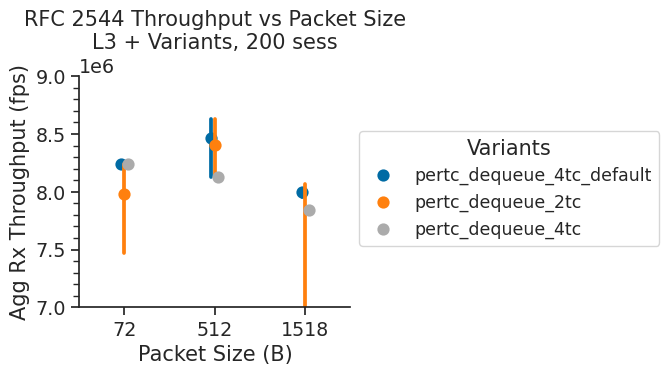

In [71]:
# Extract Flowtable variants
ft_df = combined_df
ft_encap_df = combined_df


fig, ax1 = plt.subplots(nrows=1, ncols=1, figsize=[3.5, 3])

# Compute line-rate curve
line_rate_bps = 100  # Gbps
packet_sizes = [68, 128, 256, 512, 1024, 1280, 1518]
pps_values = [(line_rate_bps / (size * 8) * 10**3) for size in packet_sizes]
ax1.plot(packet_sizes, pps_values, linestyle="--", color="gray")

# --- Add Flowtable variants ---
sns.pointplot(
    data=ft_df,
    x="Framesize",
    y=ft_df["Agg Rx Throughput (fps)"],
    ax=ax1,
    hue='Label',
    # marker="^",
    # color="blue",
    join=False,
    dodge=True,
   # label="Flowtable",
    hue_order=['pertc_dequeue_4tc_default', 'pertc_dequeue_2tc', 'pertc_dequeue_4tc'],
)

# Formatting
ax1.set_xlabel("Packet Size (B)")
# ax1.set_ylabel("Throughput (Mpps)")
ax1.set_title("RFC 2544 Throughput vs Packet Size\nL3 + Variants, 200 sess")
ax1.set_ylim(7E6, 9E6)

ax1.yaxis.set_major_locator(ticker.AutoLocator())
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax1.xaxis.set_major_locator(ticker.AutoLocator())
# ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())

ax1.legend(
    fontsize="small",
    title="Variants",
    loc="upper left",
    bbox_to_anchor=(1, 0.8),
)
sns.despine()
# fig.savefig('/home/rubinhus/Documents/phd/thesis/bng_offload/plots/bng_offload/baseline/vpp_l3_variants_200sess.pdf', bbox_inches="tight")

In [ ]:
### p_df = combined_df[
    combined_df["source"].str.contains("BNG")
]

p_df["Hyperthreading"] = p_df["source"].apply(
    lambda s: "On" if "SMT" in s else "Off"
)
fig, ax1 = plt.subplots(nrows=1, ncols=1, figsize=[3.5, 3])

# Filter for frame size 64
# p64_df = combined_df[combined_df["Framesize"] == 64].copy()

# ax1.set_yscale('log')

line_rate_bps = 100  # 100 Gbps
packet_sizes = [68, 128, 256, 512, 1024, 1280, 1518]  # RFC 2544 sizes
ethernet_overhead = 0  # Overhead in bytes

# Compute packets per second (PPS)
pps_values = [(line_rate_bps / (size * 8) * 10**3) for size in packet_sizes]
print(pps_values)
ax1.plot(
    packet_sizes,
    pps_values,
    linestyle="--",
)

sns.scatterplot(
    data=p_df,
    x="Framesize",
    y=p_df["Agg Rx Throughput (fps)"] / 10**6,
    hue="Hyperthreading",
    #style="SMT_label",
    #markers={"SMT": "o", "No SMT": "x"},
    s=50,
    ax=ax1,
)
# Label formatting
ax1.set_ylabel("Throughput (Mfps)")
ax1.set_xlabel("Packet Size (B)")
ax1.set_title("RFC 2544 Throughput vs Packet Size\nBNG, 4k sessions p core")
ax1.set_ylim(0, 20)
ax1.set_ylabel("Throughput (Mpps)")

ax1.yaxis.set_major_locator(ticker.AutoLocator())
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax1.xaxis.set_major_locator(ticker.AutoLocator())
ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())

# ax1.set_title("2x VPP 2544 throughput (64 B pkt)")


# ax1.legend(
#    loc="upper left",
#    bbox_to_anchor=(1, 0.45),
# )

sns.despine()
# fig.savefig('/home/rubinhus/Documents/phd/thesis/bng_offload/plots/bng_offload/baseline/vpp_bng_16k.pdf', bbox_inches="tight")

In [ ]:
t_df

NameError: name 'combined2_df' is not defined

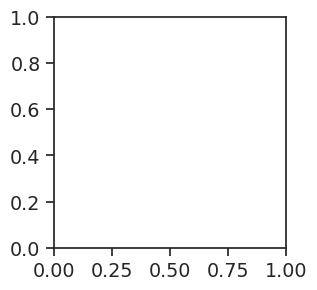

In [57]:
fig, ax1 = plt.subplots(nrows=1, ncols=1, figsize=[3, 3])

# offload_df = combined_df[combined_df['iface'] == 'offload']

line_rate_bps = 100  # 100 Gbps
packet_sizes = [64, 128, 256.0, 512.0, 1024.0, 1280.0, 1518.0]  # RFC 2544 sizes
ethernet_overhead = 0 # Overhead in bytes

t_df = combined2_df#[combined_df['hyperthreading'] == 'noht']
#t_df = t_df[t_df['Framesize'] == 64]
# t_df = t_df[t_df['queue'] == '8']

sns.pointplot(
    data = t_df,
    x = 'Framesize',
    y=t_df['Max Latency (ns)'] / 10**3- 23.957,
    # hue = 'iface',
    # style ='hyperthreading',
    join = False,
    #hue_order = ['8',"1"],
   #order=['memif','offload'],
    label='Max',
    markers='^',
    ax=ax1,
    
)

sns.pointplot(
    data = t_df,
    x = 'Framesize',
    y=t_df['Avg Latency (ns)'] / 10**3- 23.957,
    # hue = 'iface',
    # style ='hyperthreading',
    join = False,
    #hue_order = ['8',"1"],
    #order=['memif','offload'],
    label='Avg',
    ax=ax1,
)

sns.pointplot(
    data = t_df,
    x = 'Framesize',
    y=t_df['Min Latency (ns)'] / 10**3- 23.957,
    # hue = 'iface',
    # style ='hyperthreading',
    join = False,
    #hue_order = ['8',"1"],
    #order=['memif','offload'],
    label='Min',
    markers='v',
    ax=ax1,
)

ax1.yaxis.set_major_locator(ticker.AutoLocator())
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax1.xaxis.set_major_locator(ticker.AutoLocator())
ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())


# ax1.set_title('64 B Pkt Latency at 2544 Throughput\n8-noht', pad=20)
ax1.set_xlabel('Packet Size')

ax1.set_ylabel('Latency (us)')
# ax1.set_ylim(0, 500)
ax1.set_yscale('log')
legend1 = ax1.legend(
    loc="upper left",
    bbox_to_anchor=(1, 1.1),
)

sns.despine()
# fig.savefig('/home/rubinhus/Documents/phd/thesis/bng_offload/plots/testpmd_latency_8-noht.pdf', bbox_inches="tight")

## IntraProcess

In [ ]:
# Set your base directory
base_dir = '/home/rubinhus/code/datasets/saturn/hqos_intra_thread_2544/'

# Glob pattern to find all AggregateResults.csv files
csv_files = glob(os.path.join(base_dir, '*/Run0001/AggregateResults.csv'))

all_dfs = []
combined_df = []

for file in csv_files:
    # Get parent directory name (e.g., testpmd_2x_1q_memif_noht)
    parent_dir = os.path.basename(os.path.dirname(os.path.dirname(file)))

    # Extract queue info (1q or 8q)
    queue_match = re.search(r'_(1q|8q)', parent_dir)
    queue = queue_match.group(1).replace('q', '') if queue_match else 'unknown'

    # Extract HT info (siblinght or siblingnoht)
    iface = parent_dir.split('_')
    print(iface)

    # Read CSV and annotate with metadata
    try:
        df = pd.read_csv(file)
        df['threads'] = int(iface[0])
        #df['hyperthreading'] = iface[4]
        #df['source'] = parent_dir
        #df['iface'] = iface[3]
        all_dfs.append(df)
    except Exception as e:
        print(f"Failed to read {file}: {e}")

# Combine and sort
combined_df = pd.concat(all_dfs, ignore_index=True)
# combined_df = combined_df.sort_values(by='teststring')


# Optional: save to CSV
# combined_df.to_csv('/home/rubinhus/code/aggregateresults.csv', index=False)

combined_df[['Min Latency (ns)', 'Max Latency (ns)', 'Avg Latency (ns)']]-23957